# 드라이브 마운트 및 경로 이동/추가

In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [ ]:
%cd /content/drive/MyDrive/ultralytics/ultralytics
%ls

/content/drive/MyDrive/ultralytics/ultralytics
assets/                      hub/               __pycache__/       solutions/  wandb/
cfg/                         __init__.py        rtdetr-l.pt        trackers/   yolo11n.pt
data/                        models/            rtdetr-x.pt        utils/      yolo11s.pt
engine/                      NH01_YOLO.ipynb    runs/              val/        yolov8m.pt
FOOD_DETECT/                 NHC014_YOLO.ipynb  runs_food_rtdetr/  val2/       yolov8n.pt
Food_Detection_RTDETR.ipynb  NHC_DETECT/        runs_food_yolo/    val3/       yolov8n-seg.pt
Food_Detection_YOLO.ipynb    nn/                runs_HNC_yolo/     val4/       yolov8s.pt


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/ultralytics')
sys.path.append('/content/drive/MyDrive/ultralytics/ultralytics')  # Add the folder to sys.path

# 이미지 데이터 개수 확인

In [ ]:
train_image = "/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images"

In [ ]:
import os
file_count = len([file for file in os.listdir(train_image) if os.path.isfile(os.path.join(train_image, file))])
print(file_count)

8062


In [ ]:
train_label = "/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels"

In [ ]:
label_count = len([file for file in os.listdir(train_label) if os.path.isfile(os.path.join(train_label, file))])
print(label_count)

8064


In [ ]:
from collections import defaultdict

def find_duplicate_filenames(directory_path):
    file_map = defaultdict(list)

    for root, _, files in os.walk(directory_path):
        for file in files:
            file_map[file].append(os.path.join(root, file))

    duplicates = {name: paths for name, paths in file_map.items() if len(paths) > 1}

    return duplicates

# Example usage
duplicates = find_duplicate_filenames(train_label)

if duplicates:
    print("Duplicate filenames found:")
    for name, paths in duplicates.items():
        print(f"File '{name}' found at:")
        for path in paths:
            print(f"  {path}")
else:
    print("No duplicate filenames found.")


No duplicate filenames found.


# GPU 체크

In [ ]:
import os
import gc
import torch
import yaml

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# 라이브러리 및 모델 불러오기

In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 32.7/235.7 GB disk)


## 모델 불러오기

In [ ]:
from ultralytics import YOLO

model1 = YOLO("yolov8n.pt") # Load a COCO-pretrained YOLOv8n model
model2 = YOLO("yolov8s.pt")  # Load a COCO-pretrained YOLOv8s model
model3 = YOLO("yolo11n.yaml").load("yolo11n.pt")  # build from YAML and transfer weights

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Transferred 499/499 items from pretrained weights


In [ ]:
# Display model information (optional)
model2.info()

YOLOv8s summary: 225 layers, 11,166,560 parameters, 0 gradients


(225, 11166560, 0, 0.0)

# 로거 세팅

In [ ]:
!pip install -q wandb

In [ ]:
from google.colab import userdata
wandb_api = userdata.get('WANDB_API')

import wandb
wandb.login(key=wandb_api)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

## YOLOv8_Nano Train1

- Train Settings 학습 세팅 변수 레퍼런스: https://docs.ultralytics.com/modes/train/#resuming-interrupted-trainings
- 모델 트레이닝 팁 레퍼런스:
https://docs.ultralytics.com/ko/guides/model-training-tips/

In [ ]:
run = wandb.init(project="Food_YOLO",
                 name = 'train1')

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='train1',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train1',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model1)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.27 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train13, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_f

100%|██████████| 755k/755k [00:00<00:00, 83.4MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


...

                   all       1595       1707      0.697      0.605      0.637      0.358



10 epochs completed in 1.105 hours.
Optimizer stripped from runs/detect/train13/weights/last.pt, 5.7MB
Optimizer stripped from runs/detect/train13/weights/best.pt, 5.7MB

Validating runs/detect/train13/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 186 layers, 2,684,563 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:10<00:00,  4.57it/s]

                   all       1595       1707      0.639      0.644      0.646      0.368
Speed: 0.3ms preprocess, 3.1ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▃▁▂▆▃▅▅▇██
metrics/mAP50-95(B),▁▁▂▅▃▅▅▇██
metrics/precision(B),▁▃▃▆▂█▇█▇▇
metrics/recall(B),▄▁▂▅▄▄▆▆██
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▆▆▅▄▃▃▂▂▁


In [ ]:
from ultralytics import YOLO

run = wandb.init(project="Food_YOLO",
                 name = 'YOLOv8_n_val1')

In [ ]:
model_val5 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_yolo/detect/train/weights/best.pt")
metrics = model_val5.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,563 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:20<00:00,  4.76it/s]


                   all       1595       1707      0.642      0.642      0.647      0.368
Speed: 0.5ms preprocess, 3.1ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/val5


{'metrics/precision(B)': 0.6415480600325687,
 'metrics/recall(B)': 0.6420620972466315,
 'metrics/mAP50(B)': 0.6466569888597671,
 'metrics/mAP50-95(B)': 0.36752736375750417,
 'fitness': 0.3954403262677305}

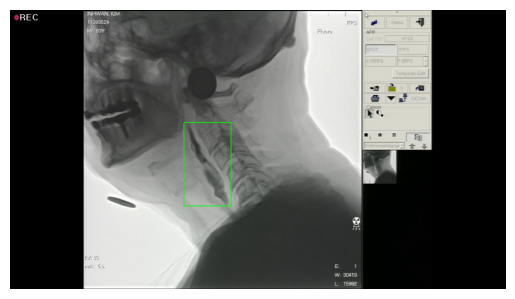

In [ ]:
# Run inference with the YOLOv8n model on the 'test_full.jpg' image
results = model1("/content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg")

import matplotlib.pyplot as plt
import cv2

# 원본 이미지를 가져오기
image = results[0].orig_img

# 탐지된 모든 박스에 대해 루프
for box in results[0].boxes.xyxy:
    x1, y1, x2, y2 = map(int, box[:4])
    # 이미지에 박스 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# 이미지 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
# 결과 이미지를 파일로 저장
plt.savefig(fname="/content/drive/MyDrive/ultralytics/ultralytics/runs/predict/yolov8_train1.jpg")
# 저장후, 보여주기. 순서가 바뀌면 빈 화면 저장하게 됌.
plt.show()

## YOLOv8_Nano Train 2


In [ ]:
run = wandb.init(project="Food_YOLO",
                 name = 'train2')

In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='train2',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,
                epochs=30,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                weight_decay=0.0005, # Lower weight decay for X-ray data
                lr0=0.005,
                # lrf=0.001, # Slower learning rate decay for precision
                # warmup_epochs=5,  # Increased warmup for smoother start
                # warmup_bias_lr=0.05,
                verbose=True,
                seed=0,
                # deterministic=False,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                # label_smoothing=0.00,
                close_mosaic=0,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train2',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model1)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.27 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train12, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_fr

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed
albumentations: 



val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed


...

                   all       1595       1707      0.673      0.649      0.672      0.402



30 epochs completed in 1.585 hours.
Optimizer stripped from runs/detect/train12/weights/last.pt, 5.7MB
Optimizer stripped from runs/detect/train12/weights/best.pt, 5.7MB

Validating runs/detect/train12/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 186 layers, 2,684,563 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:10<00:00,  4.72it/s]


                   all       1595       1707      0.737      0.602      0.669      0.404
Speed: 0.3ms preprocess, 3.1ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,▃▆██▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁
lr/pg1,▃▆██▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁
lr/pg2,▃▆██▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁
metrics/mAP50(B),▂▁▁▁▆▅▆▇▄▆▇█▇▅▇▆▇█▇▆▇▇██▇█▇███
metrics/mAP50-95(B),▂▂▁▂▅▄▄▄▅▅▆▆▄▄▅▅▆▇▇▇▆▇▇█▇▇▇███
metrics/precision(B),▁▅▃▁▄▄▄▆▄▄▆▇▅▄▅▆▇▅▆▅▆▅█▅▆▇▇▇▇▇
metrics/recall(B),▄▁▅▄▆▆▇▇▄▇▇▆▇▅▆▅▆▇▆▆▇█▅█▆▆▆▆▆▆
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▇▇▇▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁


In [ ]:
run = wandb.init(project="Food_YOLO",
                 name = 'YOLOv8_n_val2')

model_val6 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_yolo/detect/train2/weights/best.pt")
metrics = model_val6.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,563 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:13<00:00,  7.47it/s]


                   all       1595       1707      0.736      0.602      0.668      0.404
Speed: 0.6ms preprocess, 3.0ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/val6


{'metrics/precision(B)': 0.7360167574348188,
 'metrics/recall(B)': 0.6016403046280023,
 'metrics/mAP50(B)': 0.6679764007600907,
 'metrics/mAP50-95(B)': 0.40429275949049925,
 'fitness': 0.4306611236174584}

## YOLOv8_Nano Train 3

In [ ]:
run = wandb.init(project="Food_YOLO",
                 name = 'train3',
                 id='rpwdevc9',
                 resume='allow')

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


In [ ]:
from ultralytics import YOLO

# Initialize the model with the custom weights
model = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train2/weights/best.pt")

In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train3',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,  # Image size for training
                epochs=50,  # Number of epochs to train the model
                batch=8,
                augment=False,
                auto_augment= None,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                weight_decay=0.0005, # Lower weight decay for X-ray data
                lr0=0.005,
                lrf=0.01, # Dropping lr further.More gradual/slower decay(with the learning rate staying higher for longer before reducing)
                warmup_epochs=3,  # Set this for smoother start
                warmup_bias_lr=0.05,
                verbose=True,
                seed=0,
                deterministic=True,
                hsv_h=0.0,  # Disable hue shift
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=0.0,  # Disable rotation
                translate=0.0,  # Disable translation
                scale=0.0,  # Disable scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                crop_fraction=1.0, # 1.0 means no crop,
                close_mosaic=0,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train3",
                plots=False)  # Disable plotting -> Resource Efficiency Settings

# Update the WandB config settings
    wandb.config.update(args)

    print("Using device:", args['device'])  # Double-check device setting

    # Start training
    results = model.train(**args)

if __name__ == "__main__":
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.27 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train2/weights/best.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=50, time=None, patience=100, batch=8, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=Fa

100%|██████████| 755k/755k [00:00<00:00, 118MB/s]



                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


...

                   all       1595       1707      0.703      0.605      0.622      0.398

50 epochs completed in 2.421 hours.
Optimizer stripped from runs/detect/train3/weights/last.pt, 5.7MB
Optimizer stripped from runs/detect/train3/weights/best.pt, 5.7MB

Validating runs/detect/train3/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,563 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:08<00:00, 11.59it/s]

                   all       1595       1707      0.685      0.618      0.653      0.419
Speed: 0.3ms preprocess, 1.3ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,█▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▆████▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
lr/pg2,▃▆███▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
metrics/mAP50(B),▄▂▄▆▆▇█▇▅▅▅█▆▆▇▅▆▄█▆▅▄▄▇▁▇█▇▆▆▆▅▇▆▇▅▆▆▆█
metrics/mAP50-95(B),▄▁▃▃▃▅▄▅▆▆▅▆▅▇▆▇▆▅▇▆▆▇▆▆▅▅▆▇██▇▆▇▇▇▆▇▇▇▇
metrics/precision(B),▃▁▄▃▃▅▅▄▅▅▃▅▅▅▅▅▄▄▅▇▅▄▅▅▄█▅▄▅▇▇▃▅▄▅▆▆▆▅▄
metrics/recall(B),▅▂▇▃▆▆▆▇▇▇▆▅▅█▅▇█▇▅▄▇█▇▅▆▁▃██▇▇▄█▇█▆▆▆▇█
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,▇███▇▇▇▆▆▆▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁


Error: You must call wandb.init() before wandb.watch()

In [ ]:
run = wandb.init(project="Food_YOLO",
                 name = 'YOLOv8_n_val3')

model_val7 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_yolo/detect/train3/weights/best.pt")
metrics = model_val7.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,563 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:23<00:00,  4.28it/s]


                   all       1595       1707      0.683       0.62      0.652      0.419
Speed: 0.6ms preprocess, 2.9ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/val7


{'metrics/precision(B)': 0.6826915038359851,
 'metrics/recall(B)': 0.6201181526532308,
 'metrics/mAP50(B)': 0.6524228036794569,
 'metrics/mAP50-95(B)': 0.41861271864602934,
 'fitness': 0.44199372714937213}

## YOLOv8_Nano Train4

In [ ]:
# Initialize the model with the custom weights
model = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train2/weights/best.pt")

In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train4',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,  # Image size for training
                epochs=40,  # Number of epochs to train the model
                batch=16,
                augment=False,
                auto_augment= None,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                weight_decay=0.0015, # Increase the regularization
                lr0=0.001,
                lrf=0.01, # Dropping lr further.More gradual/slower decay(with the learning rate staying higher for longer before reducing)
                warmup_epochs=3,  # Set this for smoother start
                warmup_bias_lr=0.05,
                verbose=True,
                seed=0,
                deterministic=True,
                hsv_h=0.0,  # Disable hue shift
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=0.0,  # Disable rotation
                translate=0.0,  # Disable translation
                scale=0.0,  # Disable scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                crop_fraction=1.0, # 1.0 means no crop,
                close_mosaic=0,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train4",
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    # Initialize the WandB
    wandb.init(project="Food_YOLO", name = 'train4')
    # Update the WandB config settings
    wandb.config.update(args)
    # Trace/watch the model with WandB
    wandb.watch(model, log="all", log_freq=100)
    print("Using device:", args['device'])  # Double-check device setting

    # Start training
    results = model.train(**args)
    wandb.watch(model)

if __name__ == "__main__":
  main()

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


Using device: cuda
New https://pypi.org/project/ultralytics/8.3.27 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train2/weights/best.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=F

100%|██████████| 755k/755k [00:00<00:00, 27.4MB/s]



                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

...


40 epochs completed in 1.787 hours.
Optimizer stripped from runs/detect/train4/weights/last.pt, 5.7MB
Optimizer stripped from runs/detect/train4/weights/best.pt, 5.7MB

Validating runs/detect/train4/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,563 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:08<00:00,  6.09it/s]

                   all       1595       1707      0.705      0.617      0.678      0.439
Speed: 0.3ms preprocess, 1.7ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,█▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg2,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
metrics/mAP50(B),▁▆▄▇█▂▅▆▅▅▃▆▄▆▅▆▇▆▅▅▃▄▅▃▄▅▅▄▄▃▃▄▄▄▄▃▃▄▃▇
metrics/mAP50-95(B),▁▄▃▆▇▂▆▅▆▄▄▆▄▆▄▇█▇▆▇▅▅▆▅▅▆▆▆▅▅▄▆▅▄▅▄▅▅▄█
metrics/precision(B),▄▃▄▄▆▄▄▅▂▆▄▇▅▅▄▇▅▅▁▄▄▄▄█▃█▆▆▅▇▆▅▆▇▅▆▅▄▄▅
metrics/recall(B),▁█▅█▆▃▆▅▆▅▃▃▅▆▇▄▅▄▆▃▅▅▅▄▇▄▆▅▆▅▅▆▆▅▇▅▇▇▇▅
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,████▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁


Error: You must call wandb.init() before wandb.watch()

In [ ]:
run = wandb.init(project="Food_YOLO",
                 name = 'YOLOv8_n_val4')

model_val8 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_yolo/detect/train4/weights/best.pt")
metrics = model_val8.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,563 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:23<00:00,  4.22it/s]


                   all       1595       1707      0.706      0.619      0.678       0.44
Speed: 0.5ms preprocess, 2.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs/detect/val8


{'metrics/precision(B)': 0.7057531883592572,
 'metrics/recall(B)': 0.6186291739894552,
 'metrics/mAP50(B)': 0.6783076833859332,
 'metrics/mAP50-95(B)': 0.4395892414681322,
 'fitness': 0.4634610856599123}

## YOLOv11_Nano Train5
- build from YAML and transfer weights

In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='train5',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,
                epochs=10,
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment=None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train5',
                plots=False)  # Disable plotting -> Resource Efficiency Settings


    wandb.init(project="Food_YOLO", name = 'train5') # Initialize WandB

    wandb.config.update(args) # Update the WandB config settings

    print("Using device:", args['device'])  # Double-check device setting

    results = model.train(**args) # Start training # Pass args during training

    wandb.watch(model, log="all", log_freq=10) # Trace/watch the model with WandB

if __name__ == "__main__":
  main(model3)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.27 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolo11n.yaml, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train5, exist_ok=False, pretrained=yolo11n.pt, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False,

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed
albumentations: 



val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed


...

                   all       1595       1707       0.69      0.636      0.679      0.387

10 epochs completed in 0.418 hours.
Optimizer stripped from runs/detect/train5/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train5/weights/best.pt, 5.5MB

Validating runs/detect/train5/weights/best.pt...
WARNING ⚠️ validating an untrained model YAML will result in 0 mAP.
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11n summary (fused): 238 layers, 2,582,347 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:08<00:00,  6.01it/s]

                   all       1595       1707      0.691      0.636      0.679      0.388
Speed: 0.3ms preprocess, 1.9ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▁▁▂▅▃▆▄███
metrics/mAP50-95(B),▁▂▂▄▃▆▅▇██
metrics/precision(B),▁▁▃▅▃▇▄▇▇█
metrics/recall(B),▂▂▁▄▄▅▆▇██
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▇▆▅▄▄▃▂▁▁


Error: You must call wandb.init() before wandb.watch()

In [ ]:
from ultralytics import YOLO

model_val9 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_yolo/detect/train5/weights/best.pt")
metrics = model_val9.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11n summary (fused): 238 layers, 2,582,347 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:23<00:00,  4.27it/s]


                   all       1595       1707      0.688      0.636      0.678      0.387
Speed: 0.5ms preprocess, 3.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs/detect/val9


{'metrics/precision(B)': 0.6883176551244586,
 'metrics/recall(B)': 0.6362038664323374,
 'metrics/mAP50(B)': 0.677904779554354,
 'metrics/mAP50-95(B)': 0.3870268748858398,
 'fitness': 0.41611466535269126}

## YOLOv8_Small Train6
- build a new model(YOLOv11) from YAML


In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='train6',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,
                epochs=10,
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                weight_decay=0.0005,
                lr0=0.002,
                lrf=0.01, # Dropping lr further.More gradual/slower decay(with the learning rate staying higher for longer before reducing)
                warmup_epochs=2,  # Set this for smoother start
                warmup_bias_lr=0.05,
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment=None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train6',
                plots=False)  # Disable plotting -> Resource Efficiency Settings


    wandb.init(project="Food_YOLO", name = 'train6', id='qe05i2rv', resume='allow') # Initialize WandB

    wandb.config.update(args) # Update the WandB config settings

    print("Using device:", args['device'])  # Double-check device setting

    results = model.train(**args) # Start training # Pass args during training

if __name__ == "__main__":
  main(model2)

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


Using device: cuda
New https://pypi.org/project/ultralytics/8.3.27 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train62, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_

100%|██████████| 755k/755k [00:00<00:00, 81.5MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

...


10 epochs completed in 1.232 hours.
Optimizer stripped from runs/detect/train62/weights/last.pt, 20.0MB
Optimizer stripped from runs/detect/train62/weights/best.pt, 20.0MB

Validating runs/detect/train62/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,051 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  54%|█████▍    | 27/50 [00:06<00:05,  4.35it/s]wandb: WARNING Tried to log to step 10 that is less than the current step 11. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:11<00:00,  4.33it/s]

                   all       1595       1707      0.701      0.612      0.668       0.37
Speed: 0.3ms preprocess, 4.1ms inference, 0.0ms loss, 0.8ms postprocess per image



wandb: WARNING Tried to log to step 10 that is less than the current step 11. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


lr/pg0,0.00022
lr/pg1,0.00022
lr/pg2,0.00022
metrics/mAP50(B),0.54172
metrics/mAP50-95(B),0.25653
metrics/precision(B),0.55709
metrics/recall(B),0.57118
model/GFLOPs,0
model/parameters,2590035
model/speed_PyTorch(ms),2.127
train/box_loss,1.28368


## YOLOv11_Nano Train7

In [ ]:
from ultralytics import YOLO

# Initialize the model with the custom weights
model = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train5/weights/best.pt")

In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train7',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,  # Image size for training
                epochs=30,  # Number of epochs to train the model
                batch=16,
                augment=False,
                auto_augment= None,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                weight_decay=0.0015, # Increase the regularization
                lr0=0.001,
                lrf=0.01, # Dropping lr further.More gradual/slower decay(with the learning rate staying higher for longer before reducing)
                warmup_epochs=3,  # Set this for smoother start
                warmup_bias_lr=0.05,
                verbose=True,
                seed=0,
                deterministic=True,
                hsv_h=0.0,  # Disable hue shift
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=0.0,  # Disable rotation
                translate=0.0,  # Disable translation
                scale=0.0,  # Disable scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                crop_fraction=1.0, # 1.0 means no crop,
                close_mosaic=0,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir="/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train7",
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    # Ensure that wandb.init() is the very first command before any other wandb usage
    wandb.init(project="Food_YOLO", name = 'train7') # Initialize the WandB

    # Log a confirmation message to check if wandb has initialized properly
    print("WandB initialized successfully")

    # Update the WandB config settings
    wandb.config.update(args)

    # Double-check device setting
    print("Using device:", args['device'])

    # Watch the model with WandB, ensure this comes after initialization
    wandb.watch(model, log="all", log_freq=10)

    # Start training
    results = model.train(**args)


if __name__ == "__main__":
  main()

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


WandB initialized successfully
Using device: cuda
New https://pypi.org/project/ultralytics/8.3.27 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train5/weights/best.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train7, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False

100%|██████████| 755k/755k [00:00<00:00, 22.0MB/s]



                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

...

                   all       1595       1707       0.67      0.634      0.658      0.407

30 epochs completed in 1.483 hours.
Optimizer stripped from runs/detect/train7/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train7/weights/best.pt, 5.5MB

Validating runs/detect/train7/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11n summary (fused): 238 layers, 2,582,347 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:08<00:00,  5.97it/s]

                   all       1595       1707      0.682      0.652       0.67      0.408
Speed: 0.3ms preprocess, 1.9ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,█▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▃▆██▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁
lr/pg2,▃▆██▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁
metrics/mAP50(B),▄▃▄▁▆▄▅▆▇▆▇█▅▇▇▅▇▇█▇▆▇▆▆█▇▆▇▇█
metrics/mAP50-95(B),▄▂▃▁▅▄▅▆▇▅▆▇▆▇▆▅▇▇█▇▇▇▇▇██▇███
metrics/precision(B),▅▅▆▁▄▃▄▅▇▅▄▆▁▆▆▅▅▆█▄▅▆▄▇▅▆▄▄▅▅
metrics/recall(B),▁▁▁▂▆▄▁▄▄▄▆▃▇▂▄▃▆▄▄▅▅▃▅▄█▃█▆▆█
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,████▇▇▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁


Error: You must call wandb.init() before wandb.watch()

In [ ]:
from ultralytics import YOLO

model_val4 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_yolo/detect/train7/weights/best.pt")
metrics = model_val4.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11n summary (fused): 238 layers, 2,582,347 parameters, 0 gradients


100%|██████████| 755k/755k [00:00<00:00, 26.4MB/s]
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:48<00:00,  2.05it/s]


                   all       1595       1707      0.681      0.652      0.671      0.409
Speed: 0.5ms preprocess, 3.3ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/val4


{'metrics/precision(B)': 0.6813910554017558,
 'metrics/recall(B)': 0.6520210896309314,
 'metrics/mAP50(B)': 0.6706462221846683,
 'metrics/mAP50-95(B)': 0.4086544495478,
 'fitness': 0.4348536268114868}

## YOLOv8_Small Train 8

In [ ]:
from ultralytics import YOLO

# Initialize the model with the custom weights
model = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train6_2/weights/best.pt")

In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train8',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,
                epochs=30,
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                weight_decay=0.0005,
                lr0=0.001,
                lrf=0.01, # Dropping lr further.More gradual/slower decay(with the learning rate staying higher for longer before reducing)
                warmup_epochs=3,  # Set this for smoother start
                warmup_bias_lr=0.05,
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment=None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train8',
                plots=False)  # Disable plotting -> Resource Efficiency Settings


    wandb.init(project="Food_YOLO", name = 'train8') # Initialize WandB

    wandb.config.update(args) # Update the WandB config settings

    print("Using device:", args['device'])  # Double-check device setting

    results = model.train(**args) # Start training # Pass args during training

if __name__ == "__main__":
  main()

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


Using device: cuda
New https://pypi.org/project/ultralytics/8.3.27 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train6_2/weights/best.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train8, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nm

100%|██████████| 755k/755k [00:00<00:00, 112MB/s]



                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

...

                   all       1595       1707      0.715      0.631      0.681      0.424



30 epochs completed in 2.568 hours.
Optimizer stripped from runs/detect/train8/weights/last.pt, 20.0MB
Optimizer stripped from runs/detect/train8/weights/best.pt, 20.0MB

Validating runs/detect/train8/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,051 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:11<00:00,  4.45it/s]

                   all       1595       1707      0.716       0.63      0.681      0.424
Speed: 0.3ms preprocess, 4.1ms inference, 0.0ms loss, 0.8ms postprocess per image


lr/pg0,█▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▃▆██▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁
lr/pg2,▃▆██▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁
metrics/mAP50(B),▅▂▁▃▇▄▅▆▆▆▄▆▇▄▇▅▆▆▇▇▆▇▆▇▇▇████
metrics/mAP50-95(B),▃▁▁▃▅▃▄▄▄▅▃▆▆▄▆▅▆▆▇▇▇▇▇▇█▇████
metrics/precision(B),█▂▁▃▆▅▇▅▆▅▅▆▆▄▇▅▅▆█▇▆▇▆█▇▇▆▇▇█
metrics/recall(B),▅▂▃▄▃▃▄▆▅▅▃▇▆▁▄▅▅▄▅▅▆█▇▅▇▇█▇█▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,▇████▇▇▇▇▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁


In [ ]:
from ultralytics import YOLO

model_val2 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_yolo/detect/train8/weights/best.pt")
metrics = model_val2.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,051 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:28<00:00,  3.53it/s]


                   all       1595       1707      0.714      0.634      0.682      0.424
Speed: 0.5ms preprocess, 7.1ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/val2


{'metrics/precision(B)': 0.7141830374615312,
 'metrics/recall(B)': 0.6338605741066198,
 'metrics/mAP50(B)': 0.6824914848192396,
 'metrics/mAP50-95(B)': 0.42363552235251234,
 'fitness': 0.4495211185991851}

## YOLOv8_Small Train9

In [ ]:
from ultralytics import YOLO

# Initialize the model with the custom weights
model = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train8/weights/best.pt")

In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train9',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,
                epochs=50,
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                weight_decay=0.0015,
                lr0=0.002,
                lrf=0.01, # Dropping lr further.More gradual/slower decay(with the learning rate staying higher for longer before reducing)
                warmup_epochs=5,  # Set this for smoother start
                warmup_bias_lr=0.05,
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment=None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train9',
                plots=False)  # Disable plotting -> Resource Efficiency Settings


    wandb.init(project="Food_YOLO", name = 'train9', id='codskks5', resume='allow') # Initialize WandB

    wandb.config.update(args) # Update the WandB config settings

    print("Using device:", args['device'])  # Double-check device setting

    results = model.train(**args) # Start training # Pass args during training

if __name__ == "__main__":
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.27 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train8/weights/best.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train92, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


albumentations: 


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.21 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

...

                   all       1595       1707      0.701      0.596      0.675      0.434



50 epochs completed in 3.356 hours.
Optimizer stripped from runs/detect/train92/weights/last.pt, 20.0MB
Optimizer stripped from runs/detect/train92/weights/best.pt, 20.0MB

Validating runs/detect/train92/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,051 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:11<00:00,  4.36it/s]

                   all       1595       1707      0.692      0.627      0.693      0.449
Speed: 0.3ms preprocess, 4.1ms inference, 0.0ms loss, 0.8ms postprocess per image


lr/pg0,█▆▅▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▂▄▅▇███▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁
lr/pg2,▂▄▅▇███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁
metrics/mAP50(B),▆▅▅▅▁▇▆▇█▇▇▇▆▇▇▆▇▇▇█▇▇▇▇▇▇▇▇████████████
metrics/mAP50-95(B),▃▂▂▂▁▃▄▄▄▆▆▅▅▃▅▆▆▅▆▇▇▆▆▆▆▆▆▆▇▇█▇▇▇▇▇▇▇▇█
metrics/precision(B),▄▅▃▃▄▄▃▅▇▇▆▅▄▇▅▁▄▆▄▆▅▆▆▆▄█▅▅▇▆▆▆▆█▇▆▇▇▇▆
metrics/recall(B),▅▁▅▃▁▆▇▅██▇▅▆▆▆▆█▅▆▇██▇▅▆▇▄▅██▇▇▇▅▅▆▅▆▄█
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,▅▆▇████▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁


In [ ]:
from ultralytics import YOLO

model_val3 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_yolo/detect/train9/weights/best.pt")
metrics = model_val3.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,051 parameters, 0 gradients


100%|██████████| 755k/755k [00:00<00:00, 24.1MB/s]
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [01:05<00:00,  1.53it/s]


                   all       1595       1707      0.693      0.626      0.694      0.448
Speed: 0.5ms preprocess, 6.9ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val3


{'metrics/precision(B)': 0.6927175007907824,
 'metrics/recall(B)': 0.6262448740480375,
 'metrics/mAP50(B)': 0.6937037107428949,
 'metrics/mAP50-95(B)': 0.4481917141213718,
 'fitness': 0.4727429137835242}

## YOLOv11_Nano Train10

In [ ]:
from ultralytics import YOLO

# Initialize the model with the custom weights
model = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train8/weights/best.pt")

In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train10',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,
                epochs=50,
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                weight_decay=0.0015,
                lr0=0.002,
                lrf=0.01, # Dropping lr further.More gradual/slower decay(with the learning rate staying higher for longer before reducing)
                warmup_epochs=5,  # Set this for smoother start
                warmup_bias_lr=0.05,
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment=None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train10',
                plots=False)  # Disable plotting -> Resource Efficiency Settings


    wandb.init(project="Food_YOLO", name = 'train10') # Initialize WandB

    wandb.config.update(args) # Update the WandB config settings

    print("Using device:", args['device'])  # Double-check device setting

    results = model.train(**args) # Start training # Pass args during training

if __name__ == "__main__":
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.27 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train8/weights/best.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train10, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 7528 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7528/7528 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed
albumentations: 



val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed


...

                   all       1595       1707      0.701      0.596      0.675      0.434



50 epochs completed in 3.322 hours.
Optimizer stripped from runs/detect/train10/weights/last.pt, 20.0MB
Optimizer stripped from runs/detect/train10/weights/best.pt, 20.0MB

Validating runs/detect/train10/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,051 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:11<00:00,  4.40it/s]

                   all       1595       1707      0.692      0.627      0.693      0.449
Speed: 0.3ms preprocess, 4.1ms inference, 0.0ms loss, 0.8ms postprocess per image


lr/pg0,█▆▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▂▄▅▇███▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg2,▂▄▅▇███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▁▁▁
metrics/mAP50(B),▄▂▂▂▁▄▅▆▇▆▅▅▃▆▅▆▄▅▆▆█▆▆▆▅▆▆▅▆███▇▇▇▇▇▇▇█
metrics/mAP50-95(B),▃▂▂▂▁▃▄▄▄▆▆▅▅▃▅▆▅▆▆▇▇▆▆▆▆▆▆▆▇█▇▇▇█▇▇▇▇▇█
metrics/precision(B),▄▅▃▃▄▄▃▅▇▇▆▅▆▄▇▅▅▁▆▄▆▅▆▆▆▅█▅▇▆▆▆▆█▇▆▇▇▇▆
metrics/recall(B),▆▅▇▆▁▇▇██▇▇▇▇▇▇█▇▇▇██▇▇▇█▆▆▇███▇▇▇▇▇▇▇▆█
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,▅▇███▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁


In [ ]:
model_val10 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_food_yolo/detect/train10/weights/best.pt")
metrics = model_val10.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,051 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:18<00:00,  5.39it/s]


                   all       1595       1707      0.693      0.626      0.694      0.448
Speed: 0.6ms preprocess, 6.9ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/val10


{'metrics/precision(B)': 0.6927175007907824,
 'metrics/recall(B)': 0.6262448740480375,
 'metrics/mAP50(B)': 0.6937037107428949,
 'metrics/mAP50-95(B)': 0.4481917141213718,
 'fitness': 0.4727429137835242}

## YOLOv11_Small Train11

In [ ]:
from ultralytics import YOLO

model4 = YOLO("yolo11s.pt") # Load a COCO-pretrained YOLOv11s model

In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='yolov8(s)_train11',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,
                epochs=10,
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                lrf=0.01, # Dropping lr further.More gradual/slower decay(with the learning rate staying higher for longer before reducing)
                warmup_epochs=5,  # Set this for smoother start
                warmup_bias_lr=0.05,
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment=None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train11',
                plots=False)  # Disable plotting -> Resource Efficiency Settings


    wandb.init(project="Food_YOLO", name = 'train11_yolov11(s)') # Initialize WandB

    wandb.config.update(args) # Update the WandB config settings

    print("Using device:", args['device'])  # Double-check device setting

    results = model4.train(**args) # Start training # Pass args during training

if __name__ == "__main__":
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.57 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolov8(s)_train11, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=Fa

100%|██████████| 755k/755k [00:00<00:00, 111MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 8062 images, 25 backgrounds, 0 corrupt: 100%|██████████| 8062/8062 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed


...

                   all       1595       1707        0.6      0.561      0.564      0.305



10 epochs completed in 1.331 hours.
Optimizer stripped from runs/detect/yolov8(s)_train11/weights/last.pt, 19.2MB
Optimizer stripped from runs/detect/yolov8(s)_train11/weights/best.pt, 19.2MB

Validating runs/detect/yolov8(s)_train11/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:12<00:00,  4.12it/s]

                   all       1595       1707      0.601       0.56      0.564      0.305
Speed: 0.3ms preprocess, 4.3ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,█▇▅▃▂▂▂▁▁▁
lr/pg1,▂▅▆▇█▇▅▄▂▁
lr/pg2,▂▅▆▇█▇▅▄▂▁
metrics/mAP50(B),▄▁▁▅▇▆████
metrics/mAP50-95(B),▃▁▁▅▇▅▇███
metrics/precision(B),▅▁▁▆█▆████
metrics/recall(B),▅▁▁▆▇▇████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▇▆▅▄▃▃▂▂▁


In [ ]:
model_val11 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train11/weights/best.pt")
metrics = model_val11.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:32<00:00,  3.11it/s]


                   all       1595       1707      0.601      0.561      0.566      0.305
Speed: 0.4ms preprocess, 7.6ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val11


{'metrics/precision(B)': 0.6009259069486642,
 'metrics/recall(B)': 0.5606326889279437,
 'metrics/mAP50(B)': 0.5659046717518085,
 'metrics/mAP50-95(B)': 0.30480584503644753,
 'fitness': 0.3309157277079836}

## YOLOv11_Small Train12

In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train12',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,
                epochs=30,
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                weight_decay=0.0015,
                lr0=0.002,
                lrf=0.01, # Dropping lr further.More gradual/slower decay(with the learning rate staying higher for longer before reducing)
                warmup_epochs=5,  # Set this for smoother start
                warmup_bias_lr=0.05,
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment=None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train12',
                plots=False)  # Disable plotting -> Resource Efficiency Settings


    wandb.init(project="Food_YOLO", name = 'train12_yolov11(s)') # Initialize WandB

    wandb.config.update(args) # Update the WandB config settings

    print("Using device:", args['device'])  # Double-check device setting

    results = model4.train(**args) # Start training # Pass args during training

if __name__ == "__main__":
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.57 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolov8(s)_train12, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=Fa

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 8062 images, 25 backgrounds, 0 corrupt: 100%|██████████| 8062/8062 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed
albumentations: 



val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed


...

                   all       1595       1707       0.64      0.551      0.573      0.318



30 epochs completed in 2.326 hours.
Optimizer stripped from runs/detect/yolov8(s)_train12/weights/last.pt, 19.2MB
Optimizer stripped from runs/detect/yolov8(s)_train12/weights/best.pt, 19.2MB

Validating runs/detect/yolov8(s)_train12/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:11<00:00,  4.20it/s]

                   all       1595       1707      0.662      0.554      0.592      0.335
Speed: 0.3ms preprocess, 4.3ms inference, 0.0ms loss, 0.8ms postprocess per image


lr/pg0,█▆▅▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▂▄▅▇██▇▇▇▇▆▆▆▅▅▅▅▄▄▄▄▃▃▃▂▂▂▂▁▁
lr/pg2,▂▄▅▇██▇▇▇▇▆▆▆▅▅▅▅▄▄▄▄▃▃▃▂▂▂▂▁▁
metrics/mAP50(B),▄▁▅▇▆█▄▃▆▅▂▅▇▂▅▆▆▃▄▂▄▅▄▄▄▃▄▄▃▅
metrics/mAP50-95(B),▃▂▆▅▇▇▄▃▇▇▁██▃██▇▆▇▅▆█▆▇▇▆▆▇▅█
metrics/precision(B),▁▃▄▃▆▇▄▄▄▆▂▃▇▆█▆▄▃▇▅▅▆▇▆█▆▇▆▆█
metrics/recall(B),▆▅▄█▂▅▂▃▄▃▆▆▃▃▃▅▇▄▃▂▄▄▃▃▁▂▄▄▁▃
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,███▇▇▇▇▆▆▆▅▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁


In [ ]:
model_val12 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train12/weights/best.pt")
metrics = model_val12.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:30<00:00,  3.24it/s]


                   all       1595       1707      0.662      0.554      0.592      0.334
Speed: 0.4ms preprocess, 7.5ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val12


{'metrics/precision(B)': 0.6619451915616289,
 'metrics/recall(B)': 0.5536028119507909,
 'metrics/mAP50(B)': 0.5918293994097984,
 'metrics/mAP50-95(B)': 0.3338912436615727,
 'fitness': 0.35968505923639527}

## YOLOv11_Small Train13

In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train13',
                data='/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml',
                imgsz=1088,
                epochs=50,
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                optimizer='AdamW',
                weight_decay=0.0015,
                lr0=0.002,
                lrf=0.01, # Dropping lr further.More gradual/slower decay(with the learning rate staying higher for longer before reducing)
                warmup_epochs=5,  # Set this for smoother start
                warmup_bias_lr=0.05,
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment=None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train13',
                plots=False)  # Disable plotting -> Resource Efficiency Settings


    wandb.init(project="Food_YOLO", name = 'train13_yolov11(s)') # Initialize WandB

    wandb.config.update(args) # Update the WandB config settings

    print("Using device:", args['device'])  # Double-check device setting

    results = model4.train(**args) # Start training # Pass args during training

if __name__ == "__main__":
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.57 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train13, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/labels.cache... 8062 images, 25 backgrounds, 0 corrupt: 100%|██████████| 8062/8062 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/train/images/21828027_배재희(1)SF_image053.jpg: 1 duplicate labels removed
albumentations: 



val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed


...

                   all       1595       1707      0.626      0.547       0.56      0.288



50 epochs completed in 3.888 hours.
Optimizer stripped from runs/detect/train13/weights/last.pt, 19.2MB
Optimizer stripped from runs/detect/train13/weights/best.pt, 19.2MB

Validating runs/detect/train13/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:12<00:00,  4.06it/s]

                   all       1595       1707      0.667      0.543      0.596      0.335
Speed: 0.3ms preprocess, 4.3ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,█▆▅▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▂▄▅▇██▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg2,▂▄▅▇███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁
metrics/mAP50(B),▇▅▇▆▁▆▇▃▄▆▅▆▇▄▅▄▆▇██▆▆▆▆▆▆▆▄▅█▅▇▆▅▅▅▄▅▅█
metrics/mAP50-95(B),▇▅▆▇▁▆▆▆▄▄▇▆▆▇▅▇▆█▇▇▇▆▆▆▆▆▆▆▅▅▆▅▆▅▄▄▃▃▃█
metrics/precision(B),▇▅▅▃▁▅▅▆▃▄█▅▇▆▆▅▄▃▆█▇▄▇▅▆▅▆▆▆▅▇▄▇▇▇▆▇▇██
metrics/recall(B),▅▅█▆▁▄▄▂▅▃▅▆▅▆▆▇▇█▃▄▅▆▅▅▅▅▅▄▆▆▅▇▄▄▄▄▂▃▃▃
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,██████▇▇▇▇▇▆▆▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄▃▃▃▂▂▂▂▁▁▁▁


In [ ]:
model_val13 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train13/weights/best.pt")
metrics = model_val13.val(data="/content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/yolo_customdata.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/labels.cache... 1595 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1595/1595 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/FOOD_DETECT/custom_data/FOOD/valid/images/27927869_김준자(1)SF_image054.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [00:30<00:00,  3.33it/s]


                   all       1595       1707      0.671      0.539      0.595      0.335
Speed: 0.3ms preprocess, 7.5ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val13


{'metrics/precision(B)': 0.6714682680309078,
 'metrics/recall(B)': 0.5387995583414809,
 'metrics/mAP50(B)': 0.5948498908601826,
 'metrics/mAP50-95(B)': 0.33523587899844526,
 'fitness': 0.36119728018461905}

# 로깅과 콜백 관련 레퍼런스

- logging과 callback 추가하기
- callback 레퍼런스 페이지:
  https://docs.ultralytics.com/usage/callbacks/#returning-additional-information-with-prediction
  https://docs.ultralytics.com/reference/engine/model/#ultralytics.engine.model.Model.add_callback

# 지표관련

적절한 지표 선택

Choosing the Right Metric:
  - If you want to focus on improving classification accuracy, then val/cls_loss is a good choice.
  - If you want to focus on better bounding box localization, consider val/giou_loss.
  - If smoothness or minimizing other spatial differences is important, you could optimize for val/l1_loss.